<a href="https://colab.research.google.com/github/chitrasavithri176-cmyk/python-ex/blob/main/project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('/content/appointments.csv')
display(df.head())

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
0,A001,P034,D009,09-08-2023,15:15:00,Therapy,Scheduled
1,A002,P032,D004,09-06-2023,14:30:00,Therapy,No-show
2,A003,P048,D004,28-06-2023,08:00:00,Consultation,Cancelled
3,A004,P025,D006,01-09-2023,09:15:00,Consultation,Cancelled
4,A005,P040,D003,06-07-2023,12:45:00,Emergency,No-show


In [2]:
status_counts = df['status'].value_counts()
display(status_counts)

,count
status,
No-show,52
Scheduled,51
Cancelled,51
Completed,46


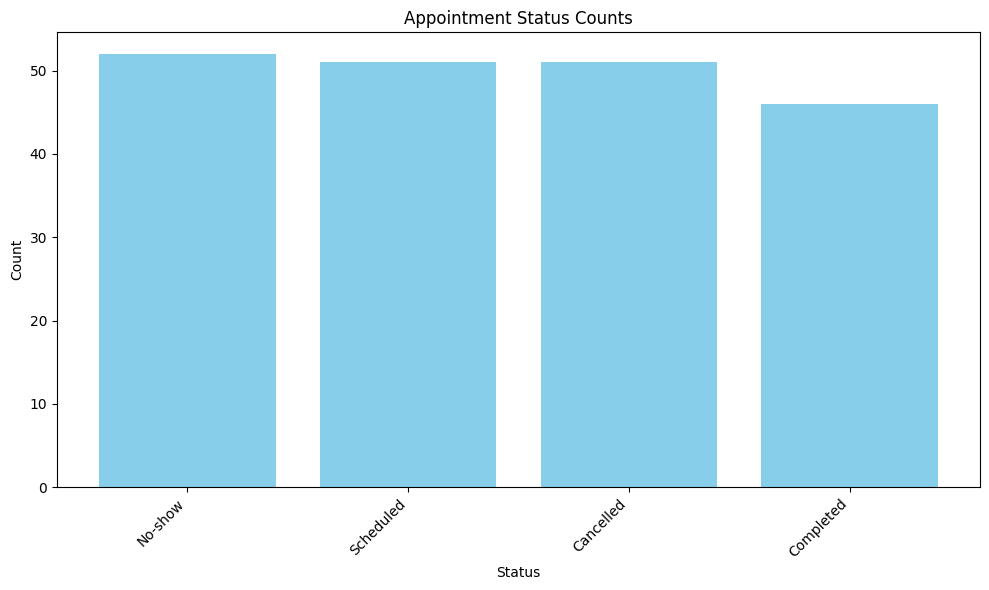

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(status_counts.index, status_counts.values, color='skyblue')
plt.title('Appointment Status Counts')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [3]:
display(df.describe(include='all'))

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
count,200,200,200,200,200,200,200
unique,200,48,10,158,40,5,4
top,A001,P012,D005,16-08-2023,11:00:00,Checkup,No-show
freq,1,10,29,5,9,45,52


In [5]:
doctor_status_counts = df.groupby('doctor_id')['status'].value_counts().unstack(fill_value=0)
display(doctor_status_counts)

status,Cancelled,Completed,No-show,Scheduled
doctor_id,,,,
D001,7,6,7,5
D002,8,5,1,7
D003,4,6,7,5
D004,3,3,5,3
D005,6,4,9,10
D006,6,5,6,7
D007,5,5,2,1
D008,5,4,4,3
D009,4,3,6,4


In [6]:
total_appointments_per_doctor = doctor_status_counts.sum(axis=1)
no_show_percentage_per_doctor = (doctor_status_counts['No-show'] / total_appointments_per_doctor * 100).round(2)

print("Percentage of 'No-show' appointments per doctor:")
display(no_show_percentage_per_doctor)

Percentage of 'No-show' appointments per doctor:


,0
doctor_id,
D001,28.00
D002,4.76
D003,31.82
D004,35.71
D005,31.03
D006,25.00
D007,15.38
D008,25.00
D009,35.29


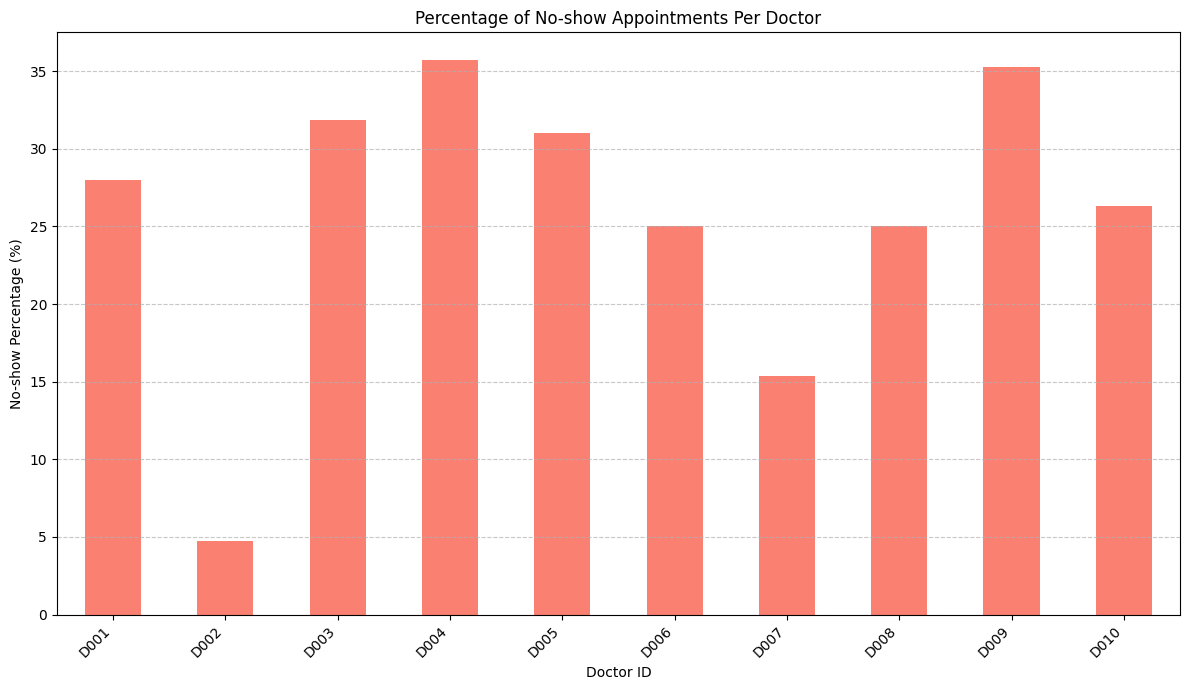

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
no_show_percentage_per_doctor.plot(kind='bar', color='salmon')
plt.title('Percentage of No-show Appointments Per Doctor')
plt.xlabel('Doctor ID')
plt.ylabel('No-show Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [8]:
average_appointments_per_doctor = total_appointments_per_doctor.mean()
print(f"Average number of appointments per doctor: {average_appointments_per_doctor:.2f}")

Average number of appointments per doctor: 20.00


In [9]:
highest_no_show_doctor = no_show_percentage_per_doctor.idxmax()
highest_no_show_percentage = no_show_percentage_per_doctor.max()

print(f"The doctor with the highest 'No-show' percentage is {highest_no_show_doctor} with {highest_no_show_percentage:.2f}%.")

The doctor with the highest 'No-show' percentage is D004 with 35.71%.


In [10]:
print("Missing values before cleaning:")
display(df.isnull().sum())

Missing values before cleaning:


,0
appointment_id,0
patient_id,0
doctor_id,0
appointment_date,0
appointment_time,0
reason_for_visit,0
status,0


If there are missing values, a common strategy for categorical or object (string) columns is to fill them with a placeholder like 'Unknown'. For numerical columns, one might use the mean, median, or 0. Based on the current dataset, most columns appear to be object types.

In [11]:
# Identify object columns to fill with 'Unknown'
object_cols = df.select_dtypes(include='object').columns
df[object_cols] = df[object_cols].fillna('Unknown')

# For demonstration, if there were numeric columns, you might do:
# numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
# df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

print("Missing values after cleaning:")
display(df.isnull().sum())

Missing values after cleaning:


,0
appointment_id,0
patient_id,0
doctor_id,0
appointment_date,0
appointment_time,0
reason_for_visit,0
status,0


In [12]:
# Convert 'appointment_date' to datetime objects for time-based analysis
df['appointment_date'] = pd.to_datetime(df['appointment_date'], format='%d-%m-%Y')

# Extract month from the appointment date
df['appointment_month'] = df['appointment_date'].dt.month_name()

In [13]:
# Group by month and status to count appointments
monthly_status_counts = df.groupby(['appointment_month', 'status']).size().unstack(fill_value=0)

# Reorder months if necessary for chronological display
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_status_counts = monthly_status_counts.reindex(month_order, fill_value=0)

display(monthly_status_counts)

status,Cancelled,Completed,No-show,Scheduled
appointment_month,,,,
January,6,1,8,5
February,3,6,3,2
March,4,4,3,8
April,7,9,5,4
May,6,6,5,2
June,2,4,6,6
July,4,5,4,3
August,3,3,3,6
September,3,2,3,3


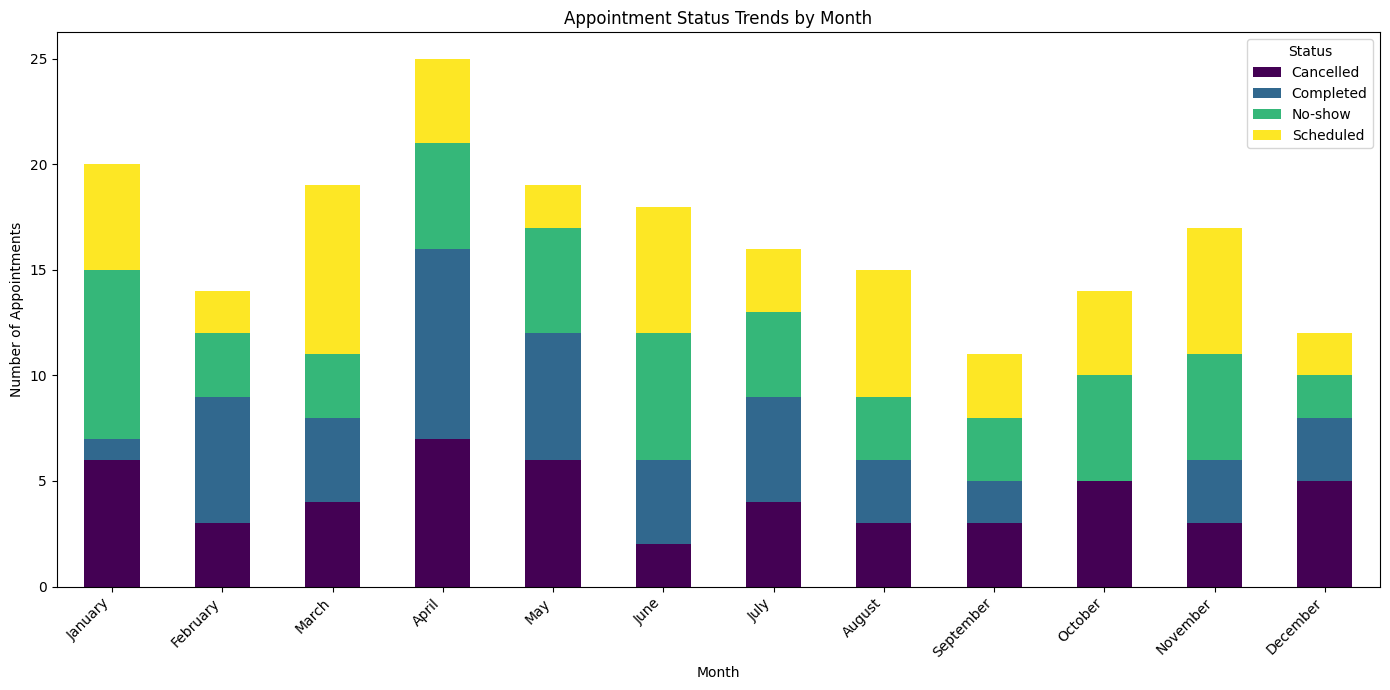

In [14]:
import matplotlib.pyplot as plt

# Plotting the monthly status counts as a stacked bar chart
monthly_status_counts.plot(kind='bar', stacked=True, figsize=(14, 7), cmap='viridis')
plt.title('Appointment Status Trends by Month')
plt.xlabel('Month')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

<Figure size 1400x700 with 0 Axes>

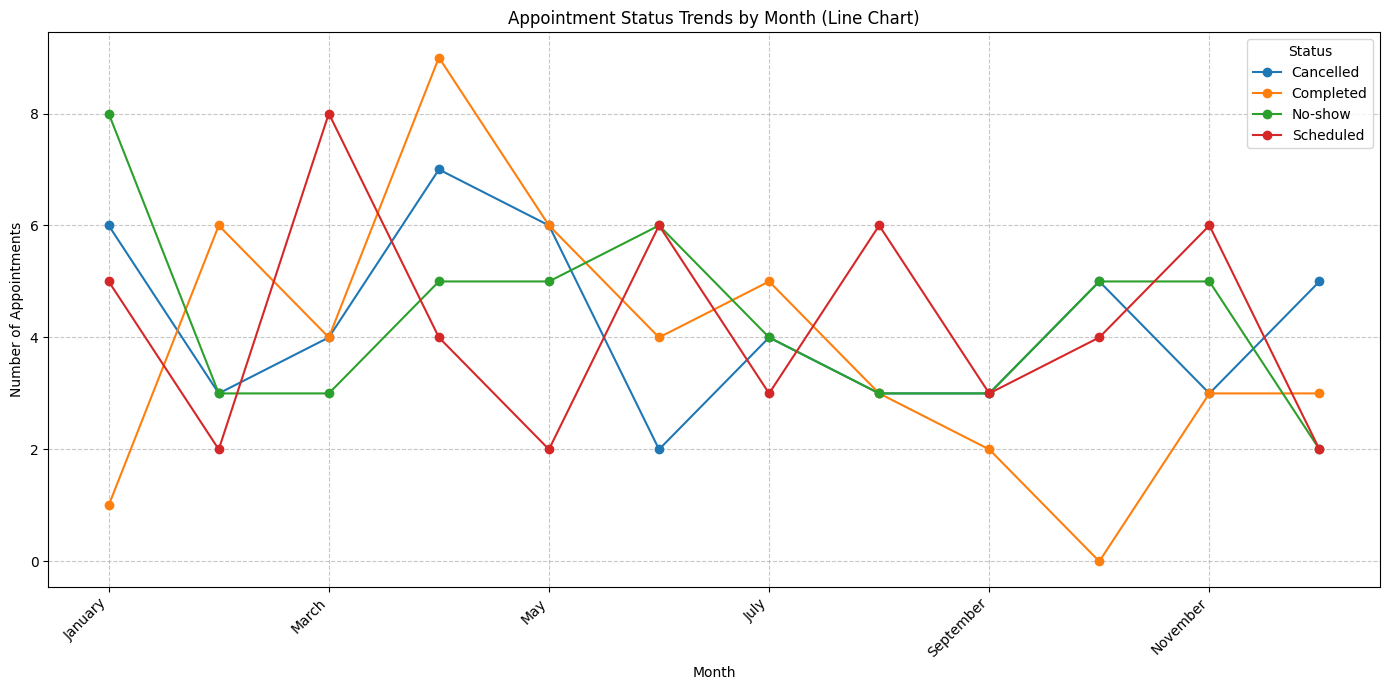

In [15]:
import matplotlib.pyplot as plt

# Plotting the monthly status counts as a line chart
plt.figure(figsize=(14, 7))
monthly_status_counts.plot(kind='line', figsize=(14, 7), marker='o')
plt.title('Appointment Status Trends by Month (Line Chart)')
plt.xlabel('Month')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Status')
plt.tight_layout()
plt.show()